# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
from pathlib import Path
import itertools
import string
import operator
import functools

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
import numpy as np

DATA_DIR = Path('data')
assert DATA_DIR.exists()


In [2]:
# PROOF OF PYTHON FAILURE MODES BY MAKING THINGS TOO COMPLEX IN THIS YEAR OF JETBRAINS vs ChatGPT vs Attachment Feature
# Eg, we're once again making things too complex for JUST VEGAS of MIDLIFE IDIOTS
# Moreover, show that someone failed my STAT MECH INTERVIEW w/ GT SoftWare around the last few cycles of Oracle w/o TikTok of RACISM PORNO
print(' '.join(
    functools.reduce(operator.add, p)
    for p in itertools.product(string.ascii_uppercase, repeat=3)
))

AAA AAB AAC AAD AAE AAF AAG AAH AAI AAJ AAK AAL AAM AAN AAO AAP AAQ AAR AAS AAT AAU AAV AAW AAX AAY AAZ ABA ABB ABC ABD ABE ABF ABG ABH ABI ABJ ABK ABL ABM ABN ABO ABP ABQ ABR ABS ABT ABU ABV ABW ABX ABY ABZ ACA ACB ACC ACD ACE ACF ACG ACH ACI ACJ ACK ACL ACM ACN ACO ACP ACQ ACR ACS ACT ACU ACV ACW ACX ACY ACZ ADA ADB ADC ADD ADE ADF ADG ADH ADI ADJ ADK ADL ADM ADN ADO ADP ADQ ADR ADS ADT ADU ADV ADW ADX ADY ADZ AEA AEB AEC AED AEE AEF AEG AEH AEI AEJ AEK AEL AEM AEN AEO AEP AEQ AER AES AET AEU AEV AEW AEX AEY AEZ AFA AFB AFC AFD AFE AFF AFG AFH AFI AFJ AFK AFL AFM AFN AFO AFP AFQ AFR AFS AFT AFU AFV AFW AFX AFY AFZ AGA AGB AGC AGD AGE AGF AGG AGH AGI AGJ AGK AGL AGM AGN AGO AGP AGQ AGR AGS AGT AGU AGV AGW AGX AGY AGZ AHA AHB AHC AHD AHE AHF AHG AHH AHI AHJ AHK AHL AHM AHN AHO AHP AHQ AHR AHS AHT AHU AHV AHW AHX AHY AHZ AIA AIB AIC AID AIE AIF AIG AIH AII AIJ AIK AIL AIM AIN AIO AIP AIQ AIR AIS AIT AIU AIV AIW AIX AIY AIZ AJA AJB AJC AJD AJE AJF AJG AJH AJI AJJ AJK AJL AJM AJN AJO AJP 

In [3]:
reports_paths = pd.Series(list(DATA_DIR.glob('*.csv')))
len(reports_paths)

20

In [4]:
reports_paths.sort_values(ascending=False).head()

18    data/cash_app_report_1783720643125.csv
4     data/cash_app_report_1783629391249.csv
10    data/cash_app_report_1783439681167.csv
11    data/cash_app_report_1783357451480.csv
19    data/cash_app_report_1783012238287.csv
dtype: object

In [5]:
most_recent_report_path = reports_paths.max()
most_recent_report_path

PosixPath('data/cash_app_report_1783720643125.csv')

In [6]:
data_raw = pd.read_csv(most_recent_report_path)
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-07-10 17:11:17 EDT,NaN,Deposits,USD,$100.00,$0.00,$100.00,NaN,NaN,NaN,COMPLETE,Add Cash,NaN,Visa debit 3333
1,2026-07-10 17:10:53 EDT,NaN,Stock Buy,USD,-$50.00,$0.00,-$50.00,AMZN,$245.34,0.203800,WAITING_ON_EXTERNAL,Scheduled $50 Purchase of Amazon,NaN,Cash Balance
2,2026-07-10 16:33:55 EDT,NaN,Stock Buy,USD,-$25.00,$0.00,-$25.00,VGLT,$54.06,0.462450,WAITING_ON_EXTERNAL,Scheduled $25 Purchase of Vanguard Long-Treasu...,NaN,Cash Balance
3,2026-07-10 11:28:58 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,WFC,$87.06,0.057430,COMPLETE,$5 Purchase of Wells Fargo,NaN,Cash Balance
4,2026-07-10 11:28:47 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,DAL,$87.04,0.114890,COMPLETE,$10 Purchase of Delta Air Lines,NaN,Cash Balance
5,2026-07-10 11:28:36 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,UHAL,$67.76,0.147570,COMPLETE,$10 Purchase of U-Haul,NaN,Cash Balance
6,2026-07-10 11:28:24 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,T,$21.12,0.473530,COMPLETE,$10 Purchase of AT&T,NaN,Cash Balance
7,2026-07-10 10:02:46 EDT,NaN,Bitcoin Sell,USD,$10.00,-$0.20,$9.80,BTC,"$63,970.87",0.000156,COMPLETE,sale of BTC 0.00015632,NaN,Cash Balance
8,2026-07-10 09:31:30 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,DELL,$448.48,0.011140,COMPLETE,$5 Purchase of Dell Technologies,NaN,Cash Balance
9,2026-07-10 09:31:04 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,ORCL,$145.20,0.034430,COMPLETE,$5 Purchase of Oracle,NaN,Cash Balance


In [7]:
data_raw.shape

(705, 14)

In [8]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
142,2026-06-22 09:30:20 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,DKS,$237.13,0.04217,COMPLETE,$10 Sale of Dick's Sporting Goods,NaN,Cash Balance
203,2026-06-16 11:45:45 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,LITE,$868.45,0.01151,COMPLETE,$10 Sale of Lumentum,NaN,Cash Balance
129,2026-06-22 13:16:52 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HIMS,$33.58,0.29775,COMPLETE,$10 Sale of Hims & Hers Health,NaN,Cash Balance
87,2026-07-01 09:35:51 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WFC,$83.02,0.24090,COMPLETE,$20 Sale of Wells Fargo,NaN,Cash Balance
48,2026-07-02 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,LITE,$778.00,0.01285,COMPLETE,$10 Sale of Lumentum,NaN,Cash Balance
176,2026-06-18 13:09:36 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,VNQ,$96.10,0.10405,COMPLETE,$10 Sale of Vanguard Real Estate ETF,NaN,Cash Balance
327,2026-06-04 09:30:07 EDT,NaN,NaN,USD,$10.21,$0.00,$10.21,OWL,$9.79,1.04329,COMPLETE,$10.21 Sale of Blue Owl Capital,NaN,Cash Balance
43,2026-07-02 13:07:21 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,V,$358.68,0.05575,COMPLETE,$20 Sale of Visa,NaN,Cash Balance
54,2026-07-02 09:30:02 EDT,NaN,NaN,USD,$6.86,$0.00,$6.86,RUM,$6.27,1.09349,COMPLETE,$6.86 Sale of RUM Group,NaN,Cash Balance
133,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance


In [9]:
data_raw['Asset Amount'].fillna(None).astype(float)

0          NaN
1      0.20380
2      0.46245
3      0.05743
4      0.11489
        ...   
700        NaN
701        NaN
702        NaN
703        NaN
704        NaN
Name: Asset Amount, Length: 705, dtype: float64

In [10]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
536,2026-06-02 16:54:39+00:00,-10.0,-10.0,84.12,0.118870,0.0,NFLX,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Netflix,NaN
511,2026-06-03 13:30:01+00:00,-1.0,-1.0,56.00,0.017850,0.0,FISV,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Fiserv,NaN
484,2026-06-03 13:30:10+00:00,-1.0,-1.0,361.85,0.002760,0.0,GOOGL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Alphabet Inc. Class A,NaN
468,2026-06-03 13:30:15+00:00,-10.0,-10.0,82.95,0.120550,0.0,NFLX,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Netflix,NaN
438,2026-06-03 14:35:31+00:00,-10.0,-10.0,78.08,0.128070,0.0,WFC,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Wells Fargo,NaN
293,2026-06-08 16:36:43+00:00,19.6,20.0,63160.58,0.000317,-0.4,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00031665,NaN
292,2026-06-08 16:37:07+00:00,5.0,5.0,85.17,0.058700,0.0,HOOD,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$5 Sale of Robinhood Markets,NaN
222,2026-06-16 13:30:14+00:00,-5.0,-5.0,594.23,0.008410,0.0,META,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Meta,NaN
42,2026-07-02 17:07:58+00:00,-10.0,-10.0,150.14,0.066600,0.0,VDE,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Energy ETF Vanguard,NaN
9,2026-07-10 13:31:04+00:00,-5.0,-5.0,145.20,0.034430,0.0,ORCL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Oracle,NaN


In [11]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
19,2026-07-09,5.0,USD,#D-55D1758ZR,Cash Balance,COMPLETE,Thank you for taking our survey!,Cash App
698,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
699,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
700,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
702,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
703,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
704,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


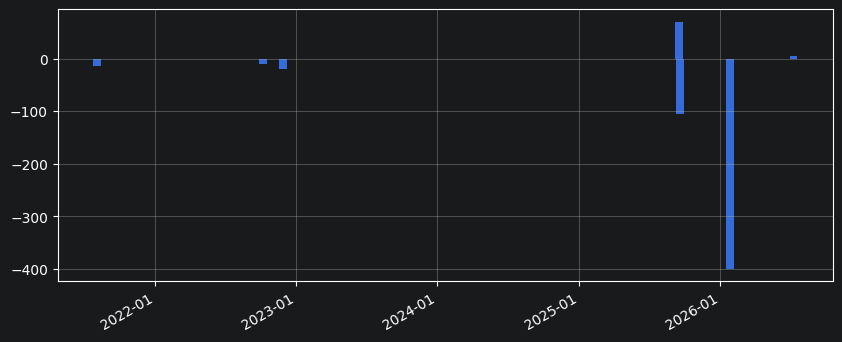

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [13]:
data.describe().round(2)

,net_amount,amount,asset_price,asset_amount,fee
count,705.00,705.00,572.00,705.00,702.00
mean,0.03,0.04,4056.76,0.14,-0.01
std,37.39,37.39,15964.81,0.33,0.05
min,-400.00,-400.00,2.22,0.00,-0.50
25%,-10.00,-10.00,57.81,0.01,0.00
50%,-10.00,-10.00,133.73,0.04,0.00
75%,-1.00,-1.00,305.58,0.13,0.00
max,200.00,200.00,80346.14,4.51,0.00


In [14]:
data.nunique().sort_values(ascending=False)

asset_price     563
asset_amount    559
date            558
notes           400
asset_type      167
amount           60
net_amount       59
trans_type       10
trans_id          8
fee               6
name_trans        6
account           5
status            3
currency          1
dtype: int64

In [15]:
data['trans_type'].fillna('NA').value_counts()

trans_type
Stock Buy                    494
Deposits                      67
Stock Sell                    46
Stock Dividends               43
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                   8
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [16]:
(data
 .assign(amount=np.abs(data['amount']))
 .groupby('trans_type')
 ['amount'].describe()
 .drop('std', axis=1)
 .round(2)
 .assign(count=lambda x: x['count'].astype(int))
 .sort_values('count', ascending=False))

,count,mean,min,25%,50%,75%,max
trans_type,,,,,,,
Stock Buy,494,10.36,1.00,10.00,10.00,10.00,50.00
Deposits,67,88.60,1.00,50.00,100.00,100.00,200.00
Stock Sell,46,10.96,3.00,8.63,10.00,10.18,20.89
Stock Dividends,43,0.09,0.01,0.04,0.07,0.14,0.30
Bitcoin Buy,24,10.29,0.98,4.90,9.80,9.80,24.50
Savings Internal Transfer,12,54.17,50.00,50.00,50.00,50.00,100.00
Bitcoin Sell,8,12.50,5.00,8.75,10.00,20.00,20.00
P2P,7,89.29,5.00,12.50,20.00,87.50,400.00
Account Notifications,3,0.00,0.00,0.00,0.00,0.00,0.00


In [17]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      32
XYZ      14
ORCL     13
AMZN     12
WFC      12
META     12
JPM      12
V        10
MCD      10
PZZA     10
DELL      9
DOW       8
MSFT      8
GOOG      8
VONV      8
GOOGL     8
UBER      8
VOO       7
NFLX      7
VMBS      7
FISV      7
HOOD      7
DAL       6
WMT       6
AAPL      6
Name: count, dtype: int64

Text(0, 0.5, 'Count')

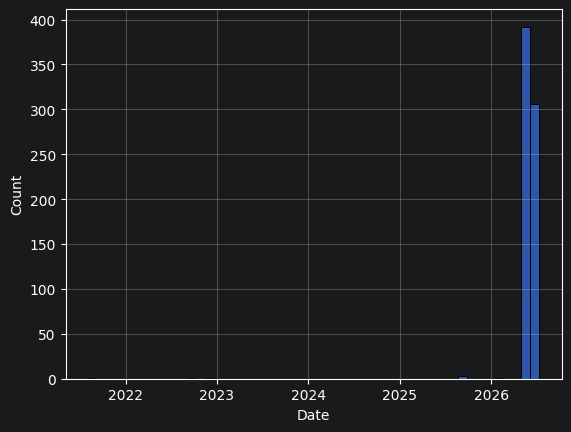

In [18]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [19]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-05-08,2026-05-27,2026-05-29,2026-06-03,2026-06-03,2026-06-18,2026-07-01,2026-07-06,2026-07-10


In [20]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,32,-146.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 10.0, 20.0)",7
XYZ,14,-181.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
ORCL,13,-110.00,"(-10.0, -5.0)",2
WFC,12,-56.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
JPM,12,-70.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
META,12,-85.95,"(-10.0, -5.0, -1.0, 0.05)",4
AMZN,12,-221.00,"(-50.0, -25.0, -10.0, -1.0)",4
PZZA,10,-85.00,"(-25.0, -10.0, -5.0, 10.0)",4
V,10,-81.00,"(-25.0, -20.0, -10.0, -5.0, -1.0, 20.0)",6


In [21]:
data['currency'].value_counts()

currency
USD    705
Name: count, dtype: int64

In [22]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    494
Deposits                      67
Stock Sell                    46
Stock Dividends               43
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                   8
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [23]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,24,8,494,43,46,615
BTC,24,8,0,0,0,32
XYZ,0,0,13,0,1,14
ORCL,0,0,13,0,0,13
AMZN,0,0,12,0,0,12
JPM,0,0,10,0,2,12
WFC,0,0,10,0,2,12
META,0,0,11,1,0,12
MCD,0,0,9,1,0,10


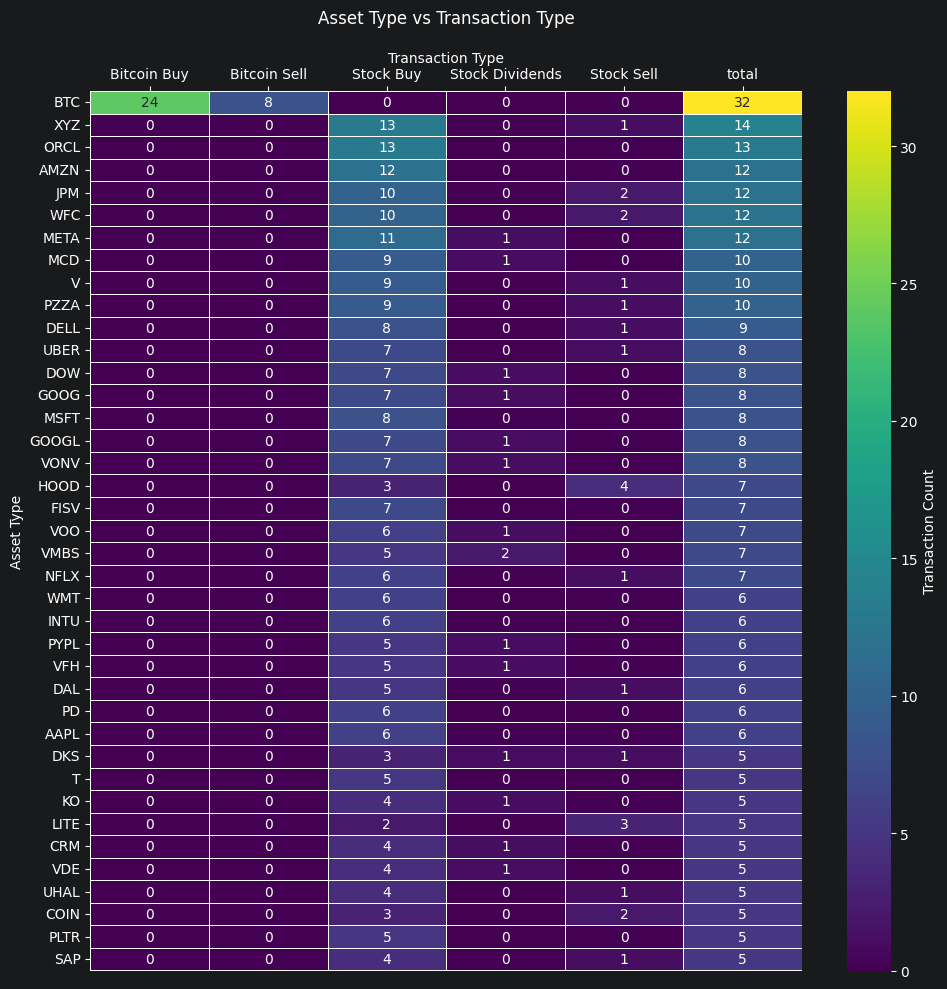

In [24]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [25]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
7,2026-07-10 14:02:46+00:00,9.8,10.0,63970.87,0.000156,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015632,NaN
28,2026-07-06 16:44:23+00:00,9.8,10.0,63170.74,0.000158,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015830,NaN
40,2026-07-02 17:10:19+00:00,19.6,20.0,61217.07,0.000327,-0.4,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN
68,2026-07-01 14:21:49+00:00,-10.0,-9.8,60409.85,0.000162,-0.2,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00016223,NaN
105,2026-06-26 17:38:10+00:00,-5.0,-4.9,60331.07,0.000081,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00008122,NaN


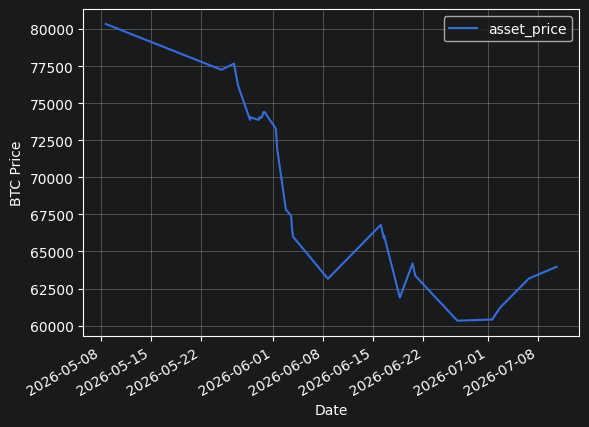

In [26]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [27]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell     8
Name: count, dtype: int64

In [28]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.0
Bitcoin Sell,98.0


In [29]:
data_btc['net_amount'].sum()

np.float64(-154.0)

In [30]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001591
Name: asset_amount, dtype: float64

In [31]:
data_btc['asset_amount'].sum()

np.float64(0.005010130000000001)

In [32]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00182911)

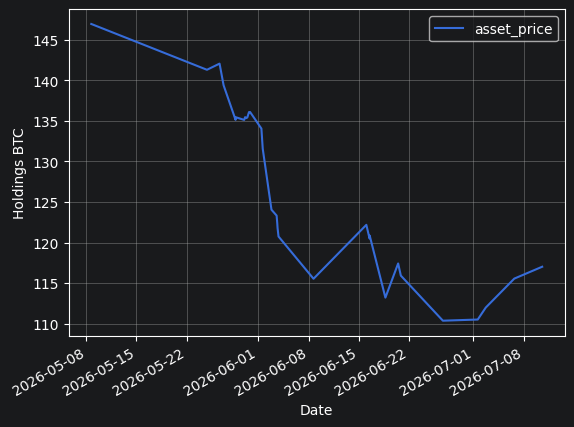

In [33]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [34]:
data_btc['asset_price'] * data_btc['asset_amount']

7       9.999926
28      9.999928
40     20.000229
68      9.800290
105     4.900090
160    10.000046
162     4.899747
171    19.999846
253     5.000156
254     4.999899
257     4.900240
293    19.999798
373     9.799846
400     9.800287
424     0.980144
521     9.800221
532     0.979969
549     9.799652
607     4.900136
609     9.799865
612     4.900112
613     9.799903
617     9.799965
621    24.500200
628    24.499951
632    24.500084
651     9.799731
655     9.800031
678    24.499991
695     9.799898
696     4.900356
697     9.799819
dtype: float64

In [35]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
23,2026-07-08 17:05:18+00:00,-10.0,-10.0,76.07,0.13145,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
104,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
133,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
215,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
260,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
308,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
384,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
396,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
409,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
447,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN


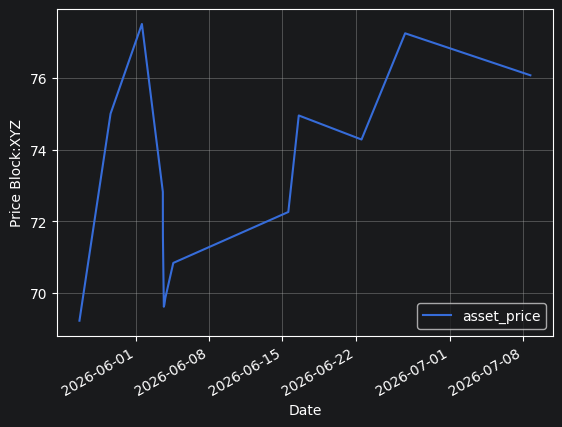

In [36]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [37]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     32
XYZ     14
ORCL    13
WFC     12
JPM     12
        ..
UNFI     1
MU       1
MSGS     1
RIVN     1
ZG       1
Name: amount, Length: 167, dtype: int64

In [38]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [39]:
data['asset_amount'].describe()

count    705.000000
mean       0.139362
std        0.327682
min        0.000000
25%        0.007920
50%        0.044200
75%        0.127090
max        4.509170
Name: asset_amount, dtype: float64

In [40]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    [data['trans_type'].isin(stock_amount_direction.keys())]
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
    .sort_index()
)
asset_holding_time.sample(10, random_state=0xCAFE).sort_index()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 13:53:46+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,20.893584,0.000000,14.039852,0.000000,...,0.000000,31.527923,9.686363,19.992722,0.0,99.663815,0.000000,9.953370,0.000000,0.000000
2026-06-03 15:06:50+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,20.893584,0.000000,14.039852,0.000000,...,0.000000,41.665912,9.686363,19.992722,0.0,99.663815,0.000000,9.953370,0.000000,0.000000
2026-06-15 13:30:21+00:00,28.691891,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,77.322328,18.724670,27.762524,0.0,154.936279,30.191289,9.953370,9.999727,9.999925
2026-06-16 13:32:08+00:00,28.691891,9.999493,11.181242,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,77.322328,18.724670,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-16 15:42:08+00:00,28.691891,9.999493,11.181242,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,81.303113,18.724670,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-18 14:06:52+00:00,28.691891,9.999493,11.181242,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,81.303113,18.724670,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-07-01 14:17:44+00:00,51.311805,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,6.862441,58.199610,23.724046,27.762524,0.0,178.314166,42.997334,19.954137,9.999727,9.999925
2026-07-02 13:30:00+00:00,51.311805,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,6.862441,58.199610,23.724046,39.646701,0.0,178.314166,52.997013,19.954137,9.999727,9.999925
2026-07-07 13:30:16+00:00,61.309073,9.999493,16.180396,8.379889,0.000000,9.999577,0.000000,21.050186,9.042617,30.069556,...,6.862441,58.199610,23.724046,49.105335,0.0,178.314166,52.997013,19.954137,9.999727,9.999925


In [41]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(4006.8501637)

In [42]:
asset_holding_time_last = asset_holding_time.iloc[-1].sort_values(ascending=False)
asset_holding_time_last.head()

asset_type
AMZN    213.016455
XYZ     188.313567
DELL    117.932301
MCD      98.010046
UBER     96.165081
Name: 2026-07-10 21:10:53+00:00, dtype: float64

In [43]:
asset_holding_time_last.tail()

asset_type
ILMN    0.0
VDC     0.0
HPQ     0.0
JEPI    0.0
BTC     NaN
Name: 2026-07-10 21:10:53+00:00, dtype: float64

In [44]:
zero_assets = asset_holding_time_last[asset_holding_time_last == 0.0].sort_index().index
zero_assets

Index(['ADP', 'ALKT', 'AVGO', 'BBEU', 'BIV', 'BNDX', 'CRM', 'CXSE', 'DKS',
       'EMB', 'FIS', 'GM', 'GSLC', 'HPQ', 'ILMN', 'JEPI', 'KO', 'KWEB', 'MRK',
       'NOBL', 'NVDA', 'OWL', 'PSKY', 'QCOM', 'RUM', 'RUN', 'TSM', 'VBR',
       'VDC', 'VFH', 'VHT', 'VMBS', 'VNQ', 'VONG', 'VSS', 'VTEB', 'XLB'],
      dtype='str', name='asset_type')

In [45]:
data[data['asset_type'].isin(zero_assets)][['asset_type', 'notes']].sort_values('asset_type')

,asset_type,notes
97,ADP,$0.15 Dividend from Automatic Data Processing
559,ADP,$10 Purchase of Automatic Data Processing
170,ADP,$10 Purchase of Automatic Data Processing
434,ADP,$10 Purchase of Automatic Data Processing
604,ALKT,$10 Purchase of Alkami Technology
...,...,...
192,VTEB,$5 Purchase of Vanguard Tax-Exempt Bond ETF
596,VTEB,$10 Purchase of Vanguard Tax-Exempt Bond ETF
37,VTEB,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF
518,XLB,$10 Purchase of Materials Select Sector SPDR


In [46]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-10 15:28:36+00:00,0.015301,0.002496,0.004038,0.004587,0.0,0.002496,0.0,0.005254,0.002257,0.007505,...,0.001713,0.014525,0.005921,0.014751,0.0,0.046998,0.013227,0.00498,0.002496,0.002496
2026-07-10 15:28:47+00:00,0.015301,0.002496,0.004038,0.004587,0.0,0.002496,0.0,0.005254,0.002257,0.007505,...,0.001713,0.014525,0.005921,0.014751,0.0,0.046998,0.013227,0.00498,0.002496,0.002496
2026-07-10 15:28:58+00:00,0.015301,0.002496,0.004038,0.004587,0.0,0.002496,0.0,0.005254,0.002257,0.007505,...,0.001713,0.015773,0.005921,0.014751,0.0,0.046998,0.013227,0.00498,0.002496,0.002496
2026-07-10 20:33:55+00:00,0.015301,0.002496,0.004038,0.004587,0.0,0.002496,0.0,0.005254,0.002257,0.007505,...,0.001713,0.015773,0.005921,0.014751,0.0,0.046998,0.013227,0.00498,0.002496,0.002496
2026-07-10 21:10:53+00:00,0.015301,0.002496,0.004038,0.004587,0.0,0.002496,0.0,0.005254,0.002257,0.007505,...,0.001713,0.015773,0.005921,0.014751,0.0,0.046998,0.013227,0.00498,0.002496,0.002496


In [47]:
asset_price_rel.iloc[-1].describe()

count    166.000000
mean       0.006024
std        0.007669
min        0.000000
25%        0.002161
50%        0.003861
75%        0.007430
max        0.053163
Name: 2026-07-10 21:10:53+00:00, dtype: float64

In [48]:
asset_price_rel_last = asset_price_rel.iloc[-1].sort_values(ascending=False)
asset_price_rel_last.head()

asset_type
AMZN    0.053163
XYZ     0.046998
DELL    0.029433
MCD     0.024461
UBER    0.024000
Name: 2026-07-10 21:10:53+00:00, dtype: float64

In [49]:
asset_price_rel_last.tail()

asset_type
ILMN    0.0
VDC     0.0
HPQ     0.0
JEPI    0.0
BTC     NaN
Name: 2026-07-10 21:10:53+00:00, dtype: float64

<Axes: ylabel='Frequency'>

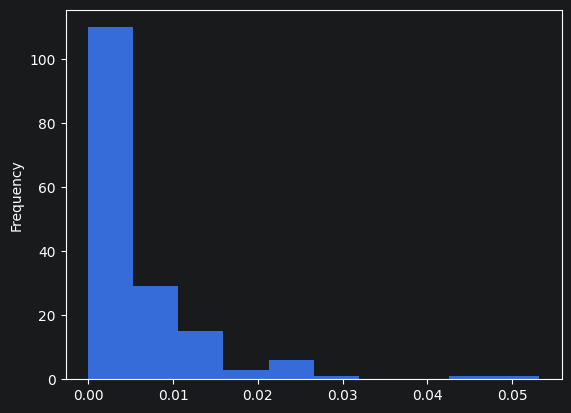

In [50]:
asset_price_rel_last.plot.hist()

In [51]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-10 15:28:36+00:00,0.015301,0.002496,0.004038,0.004587,0.0,0.002496,0.0,0.005254,0.002257,0.007505,...,0.001713,0.014525,0.005921,0.014751,0.0,0.046998,0.013227,0.00498,0.002496,0.002496
2026-07-10 15:28:47+00:00,0.015301,0.002496,0.004038,0.004587,0.0,0.002496,0.0,0.005254,0.002257,0.007505,...,0.001713,0.014525,0.005921,0.014751,0.0,0.046998,0.013227,0.00498,0.002496,0.002496
2026-07-10 15:28:58+00:00,0.015301,0.002496,0.004038,0.004587,0.0,0.002496,0.0,0.005254,0.002257,0.007505,...,0.001713,0.015773,0.005921,0.014751,0.0,0.046998,0.013227,0.00498,0.002496,0.002496
2026-07-10 20:33:55+00:00,0.015301,0.002496,0.004038,0.004587,0.0,0.002496,0.0,0.005254,0.002257,0.007505,...,0.001713,0.015773,0.005921,0.014751,0.0,0.046998,0.013227,0.00498,0.002496,0.002496
2026-07-10 21:10:53+00:00,0.015301,0.002496,0.004038,0.004587,0.0,0.002496,0.0,0.005254,0.002257,0.007505,...,0.001713,0.015773,0.005921,0.014751,0.0,0.046998,0.013227,0.00498,0.002496,0.002496


In [52]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-18 17:14:33+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-27 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 15:08:22+00:00,NaN,NaN,NaN,NaN,226.23,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-26 17:43:48+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,77.24,NaN,NaN,NaN,NaN
2026-06-02 19:54:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 13:30:03+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 15:51:44+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 13:30:24+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-10 13:30:11+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-18 17:14:33+00:00,1.018386,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-05-27 13:30:01+00:00,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.0
2026-06-03 15:08:22+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.008655,1.000000,0.955619,1.0,1.034089,1.000000,1.000000,1.0,1.0
2026-06-26 17:43:48+00:00,0.969248,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.000000,1.071179,0.921293,0.976969,1.0,1.115701,1.005550,0.995338,1.0,1.0
2026-06-02 19:54:00+00:00,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.989149,1.000000,0.955619,1.0,1.119457,1.000000,1.000000,1.0,1.0
2026-06-15 13:30:03+00:00,1.018386,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.000000,1.0,1.0
2026-06-16 15:51:44+00:00,1.018386,1.0,0.901125,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.095982,0.968648,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-06-22 13:30:24+00:00,0.969248,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.404207,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,1.005550,0.995338,1.0,1.0
2026-07-10 13:30:11+00:00,1.017280,1.0,0.719207,1.0,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

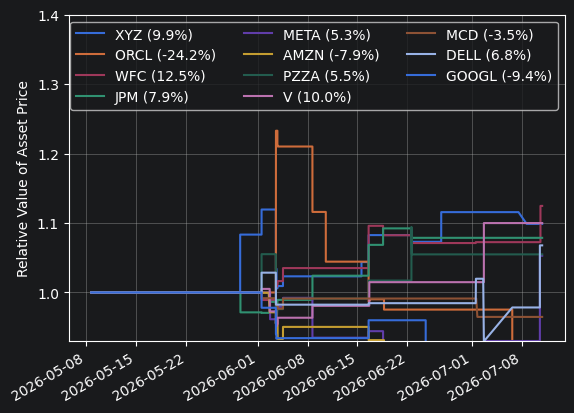

In [54]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [55]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-07-10 15:28:36+00:00    1.098801
2026-07-10 15:28:47+00:00    1.098801
2026-07-10 15:28:58+00:00    1.098801
2026-07-10 20:33:55+00:00    1.098801
2026-07-10 21:10:53+00:00    1.098801
Name: XYZ, Length: 449, dtype: float64

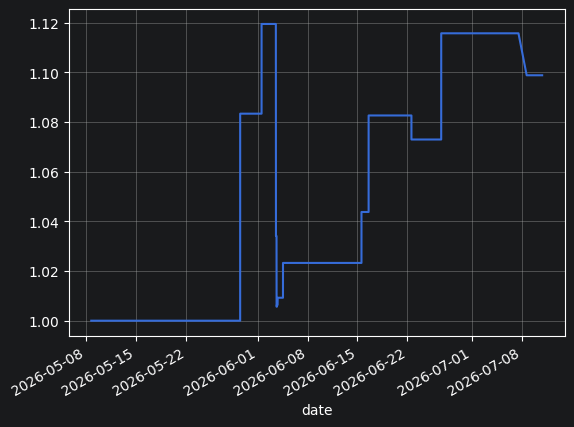

In [56]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [57]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
    .sort_values('date', ascending=False)
)
div_data

,date,amount,asset_type,notes
20,2026-07-09,0.02,TSM,$0.02 Dividend from Taiwan Semiconductor Manuf...
24,2026-07-08,0.07,MRK,$0.07 Dividend from Merck
34,2026-07-06,0.04,BIV,$0.04 Dividend from Vanguard Intermediate Term...
35,2026-07-06,0.07,JEPI,$0.07 Dividend from JPMorgan Equity Premium In...
36,2026-07-06,0.05,BNDX,$0.05 Dividend from Vanguard Total Internation...
37,2026-07-06,0.04,VTEB,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF
38,2026-07-06,0.06,VGLT,$0.06 Dividend from Vanguard Long-Treasury ETF
39,2026-07-06,0.11,VMBS,$0.11 Dividend from Vanguard Mortgage-Backed S...
58,2026-07-02,0.05,CRM,$0.05 Dividend from Salesforce
97,2026-07-01,0.15,ADP,$0.15 Dividend from Automatic Data Processing


In [58]:
div_data['amount'].sum()

np.float64(4.03)

In [59]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
109,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
94,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
116,2026-06-25,0.26,BBEU,$0.26 Dividend from JPMorgan BetaBuilders Euro...
112,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
255,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
106,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF
95,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
107,2026-06-26,0.17,DKS,$0.17 Dividend from Dick's Sporting Goods
126,2026-06-23,0.16,VSS,$0.16 Dividend from Vanguard FTSE All World ex...
97,2026-07-01,0.15,ADP,$0.15 Dividend from Automatic Data Processing


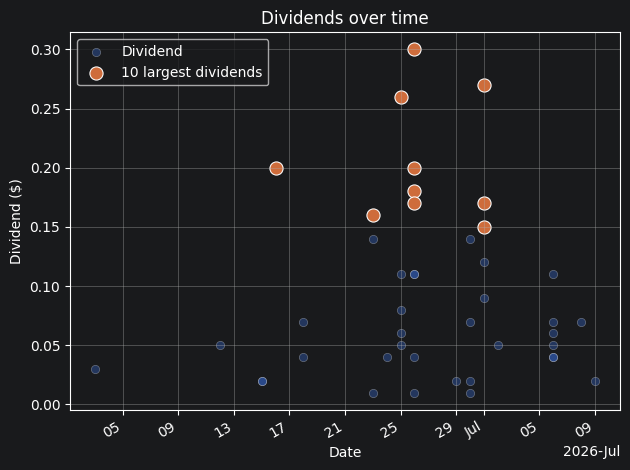

In [60]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [61]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
57,2026-07-02 13:30:00+00:00,-10.00,76.38,$10 Purchase of Vanguard Intermediate Term Bon...,BIV
437,2026-06-03 15:06:50+00:00,-10.00,159.33,$10 Purchase of Vanguard FTSE All World ex US ...,VSS
208,2026-06-16 15:43:17+00:00,-5.00,46.83,$5 Purchase of Vanguard Mortgage-Backed Securi...,VMBS
269,2026-06-15 13:30:12+00:00,-10.00,231.00,$10 Purchase of Vanguard Consumer Staples Inde...,VDC
580,2026-06-01 13:30:16+00:00,-25.00,160.89,$25 Purchase of Energy ETF Vanguard,VDE
210,2026-06-16 15:42:33+00:00,-5.00,55.01,$5 Purchase of Vanguard Long-Treasury ETF,VGLT
91,2026-07-01 13:30:01+00:00,-10.00,684.60,$10 Purchase of Vanguard S&P 500 ETF,VOO
262,2026-06-15 13:30:28+00:00,-10.00,127.25,$10 Purchase of Vanguard Russell 1000 Growth ETF,VONG
347,2026-06-03 19:46:16+00:00,-10.00,275.16,$10 Purchase of Vanguard Health Care ETF,VHT
39,2026-07-06 04:00:00+00:00,0.11,NaN,$0.11 Dividend from Vanguard Mortgage-Backed S...,VMBS


In [62]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VONV    8
VOO     7
VMBS    7
VFH     6
VDE     5
VGLT    4
VCR     4
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
BSV     1
Name: count, dtype: int64

In [63]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
57,2026-07-02 13:30:00+00:00,-10.00,76.38,BIV,Vanguard Intermediate Term Bond ETF
437,2026-06-03 15:06:50+00:00,-10.00,159.33,VSS,Vanguard FTSE All World ex US Small Cap ETF
208,2026-06-16 15:43:17+00:00,-5.00,46.83,VMBS,Vanguard Mortgage-Backed Securities ETF
269,2026-06-15 13:30:12+00:00,-10.00,231.00,VDC,Vanguard Consumer Staples Index Fund ETF
580,2026-06-01 13:30:16+00:00,-25.00,160.89,VDE,Energy ETF Vanguard
210,2026-06-16 15:42:33+00:00,-5.00,55.01,VGLT,Vanguard Long-Treasury ETF
91,2026-07-01 13:30:01+00:00,-10.00,684.60,VOO,Vanguard S&P 500 ETF
262,2026-06-15 13:30:28+00:00,-10.00,127.25,VONG,Vanguard Russell 1000 Growth ETF
347,2026-06-03 19:46:16+00:00,-10.00,275.16,VHT,Vanguard Health Care ETF
39,2026-07-06 04:00:00+00:00,0.11,NaN,VMBS,NaN


In [64]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VONV        Vanguard Russell 1000 Value ETF                7
VOO         Vanguard S&P 500 ETF                           6
VFH         Vanguard Financials ETF                        5
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VDE         Energy ETF Vanguard                            4
VGLT        Vanguard Long-Treasury ETF                     3
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VCR         Vanguard Consumer Discretionary ETF            3
VHT         Vanguard Health Care ETF                       3
VNQ         Vanguard Real Estate ETF                       2
VONG        Vanguard Russell 1000 Growth ETF               2
BIV         Vanguard Intermediate Term Bond ETF            2
BNDX        Vanguard Total International Bond ETF          2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VBR         Small Cap Value ETF Vanguard                   2
VTEB        Vanguard Tax-Exem

In [65]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VONV,VOO,VMBS,VFH,VDE,VGLT,VCR,VNQ,VHT,VSS,BIV,BNDX,VTEB,VBR,VDC,VONG,BSV
date,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,NaN,NaN,NaN,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
vanguard_trans_count

asset_type
VONV    8
VOO     7
VMBS    7
VFH     6
VDE     5
VGLT    4
VCR     4
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
BSV     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

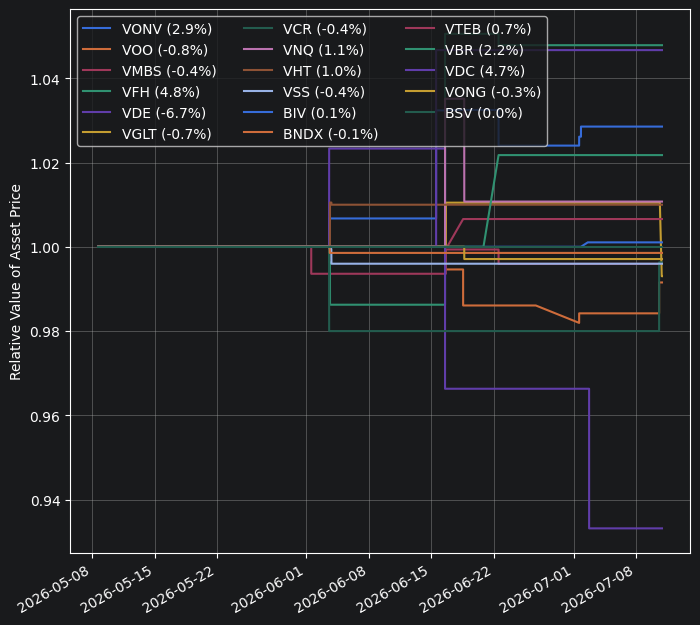

In [67]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [68]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
0,2026-07-10 21:11:17+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
18,2026-07-10 13:17:39+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
59,2026-07-01 20:14:16+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
84,2026-07-01 13:41:36+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
159,2026-06-21 21:31:19+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
689,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
690,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
691,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
692,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [69]:
data_deposits['net_amount'].sum()

np.float64(5935.96)

In [70]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,67.0,88.596418,49.239706,1.0,50.0,100.0,100.0,200.0


In [71]:
data_deposits['net_amount'].cumsum()

0       100.00
18      200.00
59      300.00
84      400.00
159     500.00
        ...   
689    5830.96
690    5840.96
691    5890.96
692    5910.96
693    5935.96
Name: net_amount, Length: 67, dtype: float64

In [72]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
693,2026-05-26 19:39:34+00:00,25.00
692,2026-05-26 21:58:29+00:00,45.00
691,2026-05-27 00:43:01+00:00,95.00
690,2026-05-27 00:56:05+00:00,105.00
689,2026-05-27 00:56:27+00:00,205.00
...,...,...
159,2026-06-21 21:31:19+00:00,5535.96
84,2026-07-01 13:41:36+00:00,5635.96
59,2026-07-01 20:14:16+00:00,5735.96
18,2026-07-10 13:17:39+00:00,5835.96


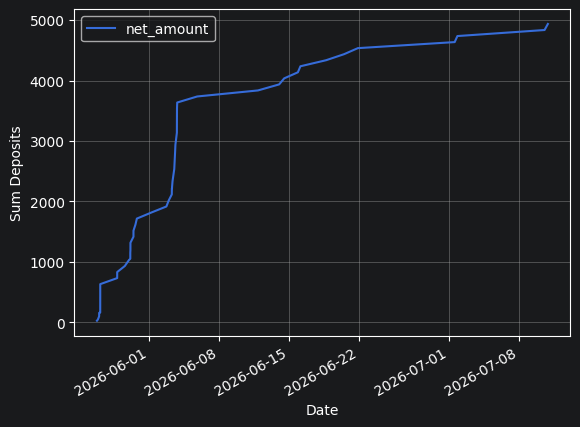

In [73]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [74]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [75]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    4600.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64